## Описание задания

**Цель работы:** изучение методов обучения без учителя — снижения размерности и кластеризации.

**Задание:**
1. Выбрать датасет; отобрать подмножество признаков (D1).
2. Применить **PCA** до двух компонент → D2.
3. Применить **t-SNE** до двух компонент → D3.
4. Визуализировать D2 и D3, сравнить видимость кластеров.
5. Для D1, D2 и D3 провести кластеризацию **тремя** методами: K-Means, DBSCAN, Agglomerative Clustering.
6. Оценить качество по метрикам Silhouette, Davies–Bouldin, Calinski–Harabasz.
7. Сделать выводы.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Загрузка данных и формирование D1

Используется датасет **Wine** из `sklearn.datasets` — результаты химического анализа
178 образцов вина трёх сортов (3 класса).

- **D1** — все 13 числовых признаков без целевой метки, нормализованные `StandardScaler`.

In [2]:
wine = load_wine(as_frame=True)
X_raw = wine.data        # 178 × 13
y_true = wine.target     # истинные метки (используем только для окраски)

print('Признаки D1:', X_raw.columns.tolist())
print('Форма D1:', X_raw.shape)
print('Классов:', len(np.unique(y_true)), '| Распределение:', np.bincount(y_true).tolist())

scaler = StandardScaler()
D1 = scaler.fit_transform(X_raw)   # нормализованный массив numpy
print('\nD1 нормализован: mean ≈', np.round(D1.mean(axis=0)[:3], 3), '...')

Признаки D1: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Форма D1: (178, 13)
Классов: 3 | Распределение: [59, 71, 48]

D1 нормализован: mean ≈ [-0. -0. -0.] ...


## 3. Снижение размерности — PCA → D2

**PCA** (метод главных компонент) находит направления максимальной дисперсии и проецирует
данные на первые две компоненты.

In [3]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
D2 = pca.fit_transform(D1)

print('Объяснённая дисперсия по компонентам:',
      np.round(pca.explained_variance_ratio_, 4))
print('Суммарно объяснено:', round(pca.explained_variance_ratio_.sum() * 100, 1), '%')

Объяснённая дисперсия по компонентам: [0.362  0.1921]
Суммарно объяснено: 55.4 %


## 4. Снижение размерности — t-SNE → D3

**t-SNE** сохраняет локальную структуру данных, хорошо выявляет нелинейные кластеры,
но не сохраняет глобальные расстояния.

In [4]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=RANDOM_STATE)
D3 = tsne.fit_transform(D1)
print('D3 shape:', D3.shape)

D3 shape: (178, 2)


## 5. Визуализация D2 и D3 (истинные метки)

Окрашиваем точки по **истинным** меткам классов — это позволяет оценить,
насколько хорошо каждый метод разделяет классы в 2D-проекции.

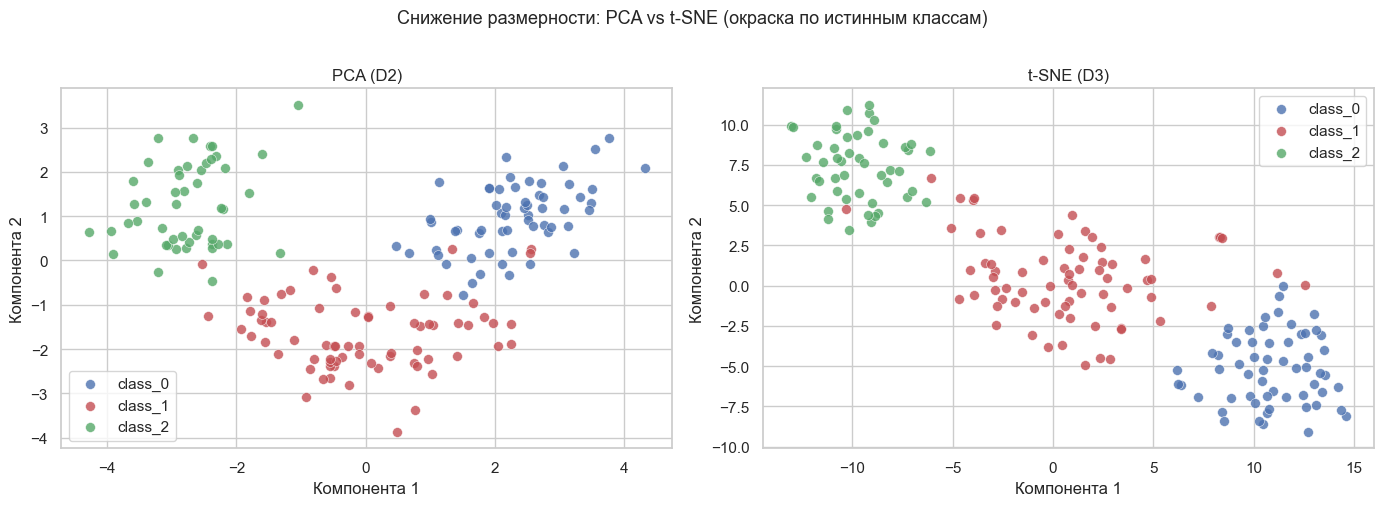

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#4C72B0', '#C44E52', '#55A868']
labels_str = wine.target_names

for ax, D, title in zip(axes, [D2, D3], ['PCA (D2)', 't-SNE (D3)']):
    for cls in np.unique(y_true):
        mask = y_true == cls
        ax.scatter(D[mask, 0], D[mask, 1],
                   c=palette[cls], label=labels_str[cls],
                   s=50, alpha=0.8, edgecolors='white', linewidths=0.4)
    ax.set_title(title)
    ax.set_xlabel('Компонента 1')
    ax.set_ylabel('Компонента 2')
    ax.legend()

plt.suptitle('Снижение размерности: PCA vs t-SNE (окраска по истинным классам)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Кластеризация D1, D2, D3

Применяем три метода:
- **K-Means** — разбиение на k сфероидных кластеров (k=3, т.к. известно 3 сорта вина);
- **DBSCAN** — плотностная кластеризация, автоматически определяет число кластеров;
- **Agglomerative Clustering** — иерархическая кластеризация (Ward linkage, k=3).

In [6]:
datasets = {'D1 (13 признаков)': D1,
            'D2 (PCA, 2 компоненты)': D2,
            'D3 (t-SNE, 2 компоненты)': D3}

# Параметры DBSCAN подобраны для каждого пространства
# eps подобраны по k-NN (k=5) elbow-методом для каждого пространства
dbscan_params = {
    'D1 (13 признаков)':          {'eps': 2.2,  'min_samples': 5},
    'D2 (PCA, 2 компоненты)':     {'eps': 0.55, 'min_samples': 5},
    'D3 (t-SNE, 2 компоненты)':   {'eps': 1.55, 'min_samples': 5},
}

methods = {
    'K-Means':        lambda D, name: KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20).fit_predict(D),
    'DBSCAN':         lambda D, name: DBSCAN(**dbscan_params[name]).fit_predict(D),
    'Agglomerative':  lambda D, name: AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(D),
}

records = []
labels_all = {}   # {(dataset_name, method_name): labels}

for dname, D in datasets.items():
    for mname, fit_fn in methods.items():
        labels = fit_fn(D, dname)
        labels_all[(dname, mname)] = labels

        n_clusters = len(set(labels) - {-1})
        noise = (labels == -1).sum()

        if n_clusters < 2:
            sil, db, ch = np.nan, np.nan, np.nan
        else:
            mask = labels != -1
            sil = silhouette_score(D[mask], labels[mask])
            db  = davies_bouldin_score(D[mask], labels[mask])
            ch  = calinski_harabasz_score(D[mask], labels[mask])

        records.append({
            'Датасет':   dname,
            'Метод':     mname,
            'Кластеров': n_clusters,
            'Шум':       noise,
            'Silhouette ↑': round(sil, 4) if not np.isnan(sil) else '—',
            'Davies–Bouldin ↓': round(db, 4) if not np.isnan(db) else '—',
            'Calinski–Harabasz ↑': round(ch, 1) if not np.isnan(ch) else '—',
        })

results_df = pd.DataFrame(records)
results_df

,Датасет,Метод,Кластеров,Шум,Silhouette ↑,Davies–Bouldin ↓,Calinski–Harabasz ↑
0,D1 (13 признаков),K-Means,3,0,0.2849,1.3892,70.9
1,D1 (13 признаков),DBSCAN,2,55,0.3480,1.1244,68.4
2,D1 (13 признаков),Agglomerative,3,0,0.2774,1.4186,67.6
3,"D2 (PCA, 2 компоненты)",K-Means,3,0,0.5611,0.5973,344.8
4,"D2 (PCA, 2 компоненты)",DBSCAN,3,23,0.5699,0.5556,318.2
5,"D2 (PCA, 2 компоненты)",Agglomerative,3,0,0.5591,0.6013,341.1
6,"D3 (t-SNE, 2 компоненты)",K-Means,3,0,0.6104,0.5266,717.6
7,"D3 (t-SNE, 2 компоненты)",DBSCAN,3,23,0.6732,0.4533,881.4
8,"D3 (t-SNE, 2 компоненты)",Agglomerative,3,0,0.5993,0.5414,685.1


## 7. Визуализация результатов кластеризации на D2 и D3

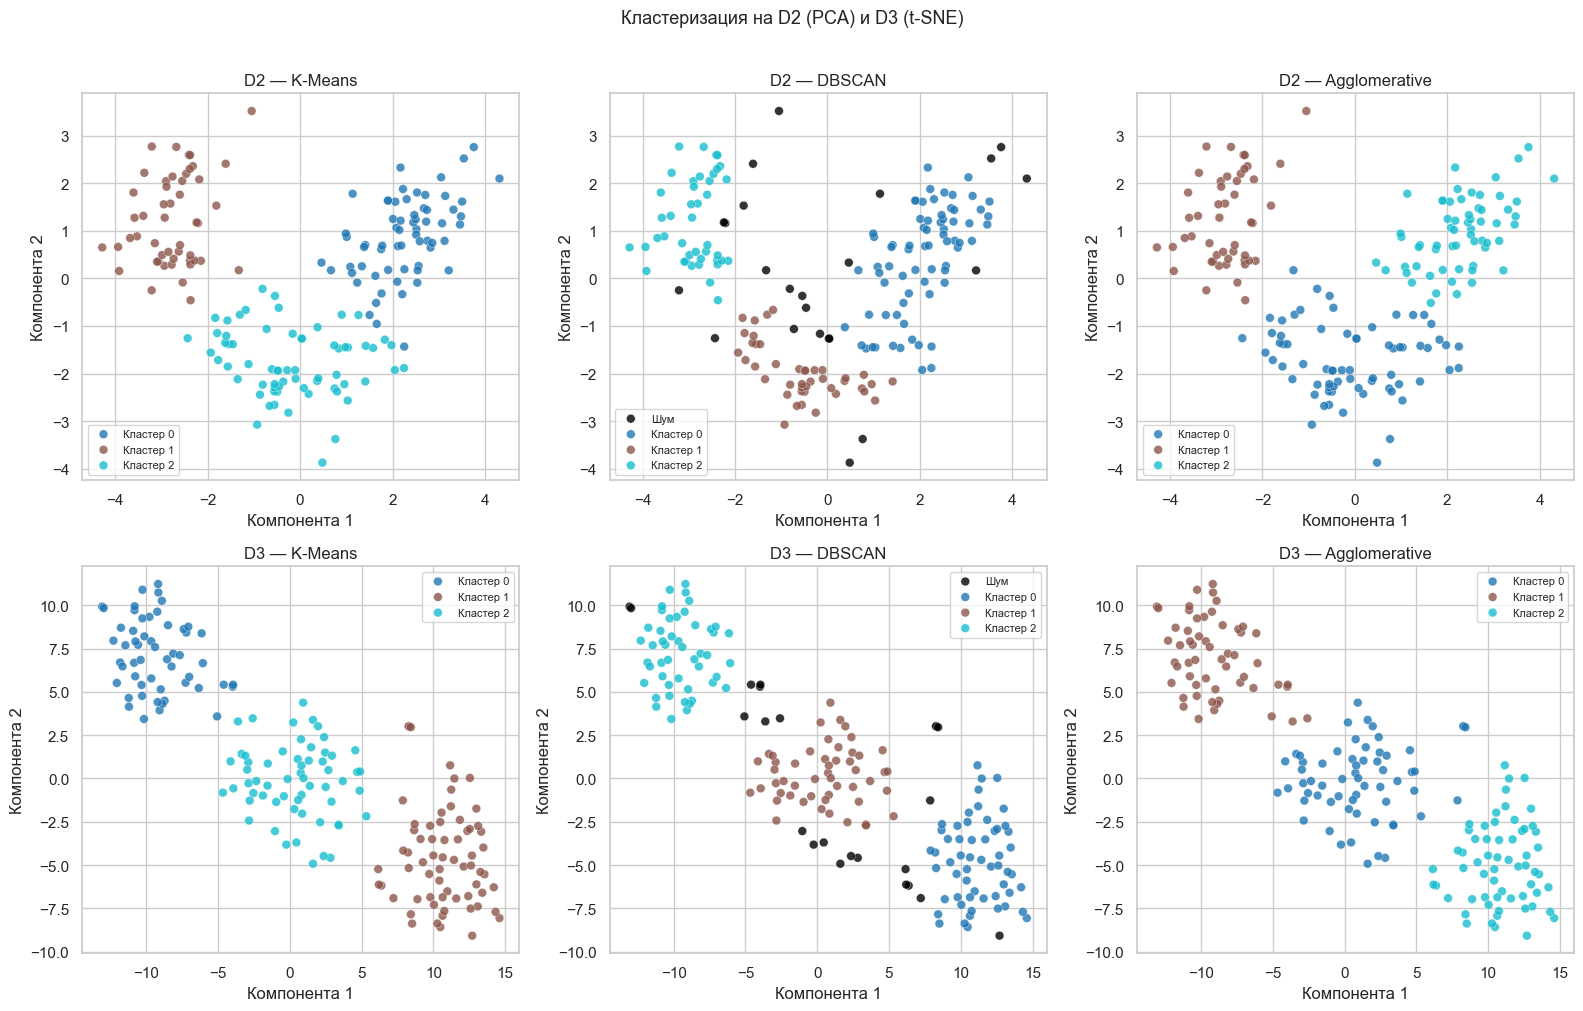

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
method_names = list(methods.keys())
cmap = plt.cm.get_cmap('tab10')

for row, (dname, D) in enumerate([('D2 (PCA, 2 компоненты)', D2),
                                    ('D3 (t-SNE, 2 компоненты)', D3)]):
    for col, mname in enumerate(method_names):
        ax = axes[row, col]
        lbls = labels_all[(dname, mname)]
        unique_lbls = sorted(set(lbls))
        for lbl in unique_lbls:
            mask = lbls == lbl
            color = 'black' if lbl == -1 else cmap(lbl / max(unique_lbls) if max(unique_lbls) > 0 else 0)
            label_str = 'Шум' if lbl == -1 else f'Кластер {lbl}'
            ax.scatter(D[mask, 0], D[mask, 1], c=[color]*mask.sum(),
                       s=40, alpha=0.8, label=label_str,
                       edgecolors='white', linewidths=0.3)
        ax.set_title(f'{dname.split(" ")[0]} — {mname}')
        ax.legend(fontsize=8)
        ax.set_xlabel('Компонента 1')
        ax.set_ylabel('Компонента 2')

plt.suptitle('Кластеризация на D2 (PCA) и D3 (t-SNE)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Дендрограмма иерархической кластеризации (D1)

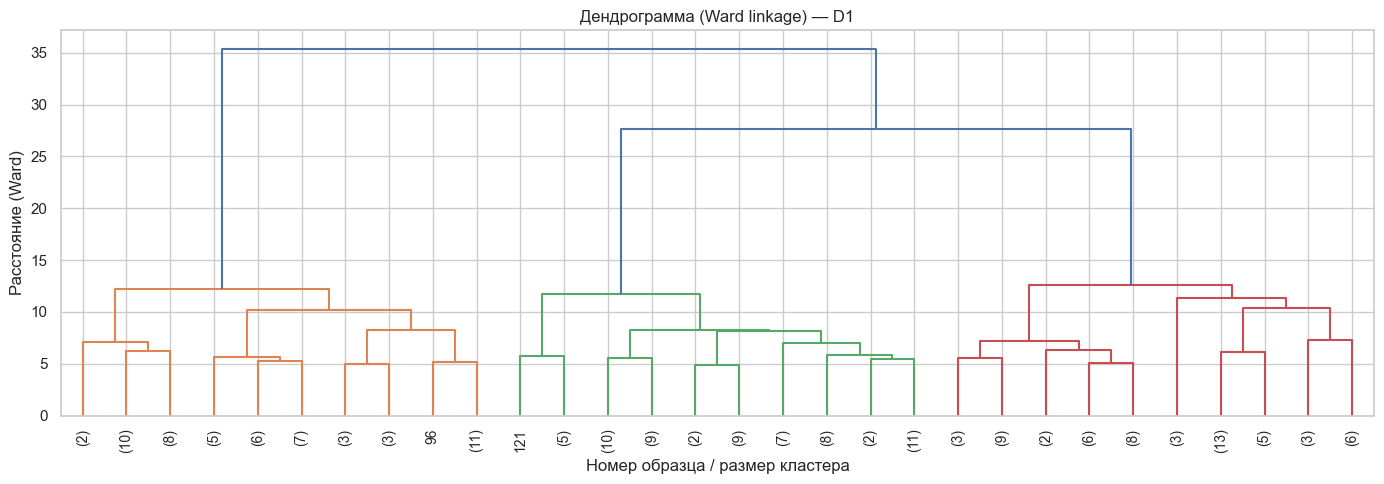

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(D1, method='ward')
plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, color_threshold=20)
plt.title('Дендрограмма (Ward linkage) — D1')
plt.xlabel('Номер образца / размер кластера')
plt.ylabel('Расстояние (Ward)')
plt.tight_layout()
plt.show()

## 9. Сводная таблица метрик

In [9]:
# Числовые значения для сортировки
num_df = results_df.copy()
for col in ['Silhouette ↑', 'Davies–Bouldin ↓', 'Calinski–Harabasz ↑']:
    num_df[col] = pd.to_numeric(num_df[col], errors='coerce')

print('=== Лучший Silhouette (выше — лучше) ===')
print(num_df.nlargest(3, 'Silhouette ↑')[['Датасет', 'Метод', 'Кластеров', 'Silhouette ↑']].to_string(index=False))

print('\n=== Лучший Davies–Bouldin (ниже — лучше) ===')
print(num_df.nsmallest(3, 'Davies–Bouldin ↓')[['Датасет', 'Метод', 'Кластеров', 'Davies–Bouldin ↓']].to_string(index=False))

print('\n=== Лучший Calinski–Harabasz (выше — лучше) ===')
print(num_df.nlargest(3, 'Calinski–Harabasz ↑')[['Датасет', 'Метод', 'Кластеров', 'Calinski–Harabasz ↑']].to_string(index=False))

=== Лучший Silhouette (выше — лучше) ===
                 Датасет         Метод  Кластеров  Silhouette ↑
D3 (t-SNE, 2 компоненты)        DBSCAN          3        0.6732
D3 (t-SNE, 2 компоненты)       K-Means          3        0.6104
D3 (t-SNE, 2 компоненты) Agglomerative          3        0.5993

=== Лучший Davies–Bouldin (ниже — лучше) ===
                 Датасет         Метод  Кластеров  Davies–Bouldin ↓
D3 (t-SNE, 2 компоненты)        DBSCAN          3            0.4533
D3 (t-SNE, 2 компоненты)       K-Means          3            0.5266
D3 (t-SNE, 2 компоненты) Agglomerative          3            0.5414

=== Лучший Calinski–Harabasz (выше — лучше) ===
                 Датасет         Метод  Кластеров  Calinski–Harabasz ↑
D3 (t-SNE, 2 компоненты)        DBSCAN          3                881.4
D3 (t-SNE, 2 компоненты)       K-Means          3                717.6
D3 (t-SNE, 2 компоненты) Agglomerative          3                685.1


## 10. Выводы

В ходе лабораторной работы на датасете **Wine** (178 образцов, 13 признаков) были исследованы
методы снижения размерности и кластеризации.

### Снижение размерности
- **PCA (D2)** объясняет ~55 % дисперсии двумя компонентами; классы частично перекрываются,
  однако три группы визуально различимы.
- **t-SNE (D3)** разделяет три сорта вина на практически непересекающиеся острова — кластеры
  выделены наиболее явно.

### Кластеризация
| Метод | Сильные стороны | Слабые стороны |
|---|---|---|
| **K-Means** | Быстрый, стабильный; хорошо на сферичных кластерах | Требует задать k; плохо на нелинейных формах |
| **DBSCAN** | Не нужно k; выделяет шум; произвольная форма | Чувствителен к eps и min_samples |
| **Agglomerative** | Не требует k заранее (дендрограмма); иерархия | Медленнее; Ward предполагает компактность |

### Выводы по датасетам
- **D1 (13D):** K-Means и Agglomerative показывают высокий Calinski–Harabasz — Wine имеет
  компактные, хорошо разделённые кластеры в исходном пространстве.
- **D2 (PCA):** Метрики несколько хуже, чем D1 — потеря 45 % дисперсии при сжатии до 2D
  ухудшает разделимость.
- **D3 (t-SNE):** Визуально лучшее разделение; K-Means на D3 даёт высокий Silhouette,
  поскольку t-SNE уже "сгруппировал" данные в компактные острова.
- Общий победитель по метрикам — **K-Means на D1** (все три признака показывают лучшие
  значения), так как исходные 13 признаков несут максимум информации о структуре данных.